# Packages, constants, and useful routines

In [ ]:
!pip install -Uq pymcel &> /dev/null
!pip install -Uq rebound &> /dev/null
import numpy as np
import pymcel as pc
import rebound as rb
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy.optimize import minimize

deg = np.pi/180
rad = 1/deg

def axis_equal(fig):
  # Calculate the range for all axes using fig.data, excluding the sphere data
  x_data = [trace.x for trace in fig.data if isinstance(trace, go.Scatter3d)]
  y_data = [trace.y for trace in fig.data if isinstance(trace, go.Scatter3d)]
  z_data = [trace.z for trace in fig.data if isinstance(trace, go.Scatter3d)]
  if len(x_data)==0:
    return

  x_data = np.concatenate(x_data)
  y_data = np.concatenate(y_data)
  z_data = np.concatenate(z_data)

  max_range = np.array([x_data.max()-x_data.min(), y_data.max()-y_data.min(), z_data.max()-z_data.min()]).max() / 2.0
  mid_x = (x_data.max()+x_data.min()) * 0.5
  mid_y = (y_data.max()+y_data.min()) * 0.5
  mid_z = (z_data.max()+z_data.min()) * 0.5

  fig.update_layout(
      scene=dict(
          aspectmode='cube',
          xaxis=dict(range=[mid_x - max_range, mid_x + max_range]),
          yaxis=dict(range=[mid_y - max_range, mid_y + max_range]),
          zaxis=dict(range=[mid_z - max_range, mid_z + max_range]))
  )

def fig_body(R, mesh3d_opts=dict(), lighting_opts=dict()):
  # Default options
  mesh3d_opts_def = dict(color='lightblue', opacity=0.5, alphahull=0)
  mesh3d_opts_def.update(mesh3d_opts)
  lighting_opts_def = dict(ambient=0.5, specular=1.0)
  lighting_opts_def.update(lighting_opts)

  # Sphere
  d=np.pi/32
  theta, phi = np.mgrid[0:np.pi+d:d, 0:2*np.pi:d]
  x = np.sin(theta) * np.cos(phi)
  y = np.sin(theta) * np.sin(phi)
  z = np.cos(theta)
  points = R*np.vstack([x.ravel(), y.ravel(), z.ravel()])
  x, y, z = points
  fig = go.Figure(data=[
      go.Mesh3d(x=x, y=y, z=z, **mesh3d_opts_def)
  ])
  fig.update_traces(lighting=lighting_opts_def)
  return fig

# New parameters
T = 0
Isp = 0
tini = 0
mini = 0
mend = 0

encendido = 0
teta = 0 # Polar angle relative to the velocity vector
phi = 0 # Azimuthal angle relative to a plane containing the velocity vector and the x-axis

def aceleracion_empuje_general_masa(simulacion):
    global T,Isp,tini,mini,mend,encendido,teta,phi

    if not encendido:
        return

    # Retrieve all simulation data
    sim = simulacion.contents

    # Retrieve the particle
    p = sim.particles[1]

    # Position, velocity, and specific angular momentum (normal to the orbit)
    rvec = np.array(p.xyz)
    r = np.linalg.norm(rvec)
    vvec = np.array(p.vxyz)
    v = np.linalg.norm(vvec)
    hvec = np.cross(rvec, vvec)

    # Calculate the thrust direction using velocity as the reference
    uvel_z = vvec / v
    uvel_x = hvec / np.linalg.norm(hvec)
    uvel_y = np.cross(uvel_z, uvel_x)

    # Calculate the mass change (only if Isp is defined)
    if Isp > 0:
      deltam = T/(Isp*g0)*(sim.t - tini)
      mend = mini - deltam
      if mend < 0:
        raise ValueError('Negative mass')

    # Calculate the specific impulse
    tau = T / mend

    tvec = tau * (np.cos(teta)*uvel_z + np.sin(teta)*np.cos(phi)*uvel_x + np.sin(teta)*np.sin(phi)*uvel_y)

    # Modify the particle acceleration
    p.ax += tvec[0]
    p.ay += tvec[1]
    p.az += tvec[2]

def mision_general_masa(m,units,orbita_inicial,maniobras):
    """A routine for designing a general mission

    Example:
        N = 100
        Xms,Ems = mision_general(
            m=1,
            units=('au','yr2pi','Msun'),
            orbita_inicial=dict(a=2,e=0),
            maniobras=[
                dict(tipo='inercial',deltat=1/2,tunit='P',N=N),
                dict(tipo='impulsiva',deltav=np.array([+0.3,0,0])),
                dict(tipo='inercial',deltat=0.5,tunit='P',N=2*N),
                dict(tipo='noimpulsiva',deltat=0.1,tunit='P',tau=0.1,N=100),
                dict(tipo='inercial',deltat=0.5,tunit='P',N=2*N),
            ]
        )
    """
    global T,Isp,tini,mini,mend,encendido,teta,phi

    # Define the simulation
    sim = rb.Simulation()
    sim.units = units
    sim.add(m=m)
    sim.add(m=0,**orbita_inicial)
    sim.additional_forces = aceleracion_empuje_general_masa
    sim.force_is_velocity_dependent = True

    # Maneuvers
    Xms = []
    Ems = []
    tms = []
    t = 0

    # Initial position
    encendido=0
    o=sim.orbits()[0]
    Xs = [list(sim.particles[1].xyz)+list(sim.particles[1].vxyz)]
    Es = [[o.a,o.e,o.inc,o.omega,o.Omega,o.f,o.M,o.P]]
    Xms += [np.array(Xs)]
    Ems += [np.array(Es)]
    tms += [t]

    for maniobra in maniobras:
        if maniobra['tipo'] == 'inercial':
            encendido = 0
            P = sim.particles[1].P
            # Choose the units for deltat
            if ('tunit' in maniobra.keys()) and maniobra['tunit']=='P':
              deltat = maniobra['deltat']*abs(P)
            else:
              deltat = maniobra['deltat']

            ts = np.linspace(t, t + deltat,
                             maniobra['N'])
            Xs = []
            Es = []
            for t_step in ts:
                sim.integrate(t_step)
                o=sim.orbits()[0]
                Xs += [list(sim.particles[1].xyz)+list(sim.particles[1].vxyz)]
                Es += [[o.a,o.e,o.inc,o.omega,o.Omega,o.f,o.M,o.P]]
            Xms += [np.array(Xs)]
            Ems += [np.array(Es)]
            tms += [ts]
            t = ts[-1] # Update the current time

        elif maniobra['tipo'] == 'impulsiva':
            encendido = 0
            sim.particles[1].vxyz += maniobra['deltav']
            o=sim.orbits()[0]
            Xs = [list(sim.particles[1].xyz)+list(sim.particles[1].vxyz)]
            Es = [[o.a,o.e,o.inc,o.omega,o.Omega,o.f,o.M,o.P]]
            Xms += [np.array(Xs)]
            Ems += [np.array(Es)]
            tms += [sim.t]

        elif maniobra['tipo'] == 'impulsada':
            encendido = 1
            tini = sim.t
            P = sim.particles[1].P

            # Choose the units for deltat
            if ('tunit' in maniobra.keys()) and maniobra['tunit']=='P':
              deltat = maniobra['deltat']*abs(P)
            else:
              deltat = maniobra['deltat']

            # New changes introduced for variable mass
            T = maniobra.get('T',0)
            Isp = maniobra.get('Isp',0)
            mini = maniobra.get('mini',0)
            mend = mini # At the beginning, final mass equals initial mass

            teta = maniobra.get('teta', 0) # Default to 0 if not provided
            phi = maniobra.get('phi', 0)   # Default to 0 if not provided
            encendido = True
            ts = np.linspace(t, t + deltat,
                             maniobra['N'])
            Xs = []
            Es = []

            # Initialize the engine ignition time
            tini = sim.t
            for t_step in ts:
                sim.integrate(t_step)
                o=sim.orbits()[0]
                Xs += [list(sim.particles[1].xyz)+list(sim.particles[1].vxyz)]
                Es += [[o.a,o.e,o.inc,o.omega,o.Omega,o.f,o.M,o.P]]
            Xms += [np.array(Xs)]
            Ems += [np.array(Es)]
            tms += [ts]
            encendido = 0
            t = ts[-1] # Update the current time

        else:
            raise Exception('Unrecognized maneuver type')

    return maniobras, tms, Xms, Ems

def dibuja_mision(fig, mision):
  maniobras, tms, Xms, Ems = mision

  colors = ['blue', 'red', 'green', 'purple', 'orange']

  # First point
  segment=Xms[0]
  fig.add_trace(go.Scatter3d(
                  x=[segment[0, 0]], y=[segment[0, 1]], z=[segment[0, 2]],
                  mode='markers',
                  marker=dict(color='black', symbol='circle', size=2),
                  name=f'Initial',
                  showlegend=True
              ))

  for i, segment in enumerate(Xms[1:]):
      maniobra = maniobras[i]

      if maniobra['tipo'] == 'inercial':
        fig.add_trace(go.Scatter3d(
            x=segment[:, 0], y=segment[:, 1], z=segment[:, 2],
            mode='lines',
            line=dict(color=colors[i % len(colors)]),
            name=f'Inertial {i+1}'
        ))

      if maniobra['tipo'] == 'impulsada':
        fig.add_trace(go.Scatter3d(
            x=segment[:, 0], y=segment[:, 1], z=segment[:, 2],
            mode='lines',
            line=dict(color=colors[i % len(colors)]),
            name=f'Powered {i+1}'
        ))
        # Draw thrust vectors
        N = maniobra['N']
        for j in range(len(segment))[::int(N/10)]:
          vvec = segment[j,3:]
          v = np.linalg.norm(vvec)
          rvec = segment[j,:3]
          r = np.linalg.norm(rvec)
          hvec = np.cross(rvec, vvec)

          # Calculate the thrust direction
          uvel_z = vvec / v
          uvel_x = hvec / np.linalg.norm(hvec)
          uvel_y = np.cross(uvel_z, uvel_x)
          tvec = 0.1*r*(np.cos(teta)*uvel_z + np.sin(teta)*np.cos(phi)*uvel_x + np.sin(teta)*np.sin(phi)*uvel_y)

          fig.add_trace(
              go.Scatter3d(
                  x=[segment[j, 0], segment[j, 0] + tvec[0]],
                  y=[segment[j, 1], segment[j, 1] + tvec[1]],
                  z=[segment[j, 2], segment[j, 2] + tvec[2]],
                  mode='lines',
                  line=dict(color='black', width=2),
                  showlegend=False,
              )
          )

      if maniobra['tipo'] == 'impulsiva':
        fig.add_trace(go.Scatter3d(
            x=segment[:, 0], y=segment[:, 1], z=segment[:, 2],
            mode='markers',
            marker=dict(color='black', symbol='diamond',size=3),
            showlegend=False,
        ))
        distance = np.linalg.norm(segment[0, :3])
        scalev = np.linalg.norm(segment[:,3:],axis=1).mean()

        deltav = maniobras[i]['deltav']/scalev*distance*0.5
        fig.add_trace(
            go.Scatter3d(
                x=[segment[0, 0], segment[0, 0] + deltav[0]],
                y=[segment[0, 1], segment[0, 1] + deltav[1]],
                z=[segment[0, 2], segment[0, 2] + deltav[2]],
                mode='lines',
                line=dict(color='black', width=2),
                name=f'Impulsive {i+1}',
                showlegend=True,
            )
        )

  fig.update_layout(legend=dict(y=0.5,yanchor='bottom'))

pymcel version  0.6.31


# Units and constants

To begin, let us define some conversion factors between SI and aerospace units (km):

In [ ]:
UM = 1 # Factor to convert our units (kg) to kg
UL = 1000 # Factor to convert our units (km) to m
UT = 1 # Factor to convert our units (s) to s
UV = UL/UT # Velocity factor
UA = UV/UT # Acceleration factor
UF = UM*UA # Force factor
URHO = UM/UL**3
G = pc.constantes.G * (UM*UT/UL**3)

# Use the factors
ME = pc.constantes.M_earth / UM
RE = pc.constantes.R_earth / UL
g0 = G * ME / RE**2

# The Cowell method

An example of the Cowell method is what we already did for the case of a vehicle with an engine turned on:

In [ ]:
N = 300
T = 10 / UF
Isp = 3000 / UT
mini = 1000 / UM

mision = mision_general_masa(
    m=ME,
    units=('km','s','kg'),
    orbita_inicial=dict(a=10000,e=0),
    maniobras=[
        dict(tipo='impulsada',deltat=3,tunit='P',T=T,Isp=Isp,mini=mini,teta=0*deg,N=N)
    ]
)

pio.renderers.default = "png"
fig = fig_body(RE)
dibuja_mision(fig, mision)
axis_equal(fig)
fig.update_layout(width=800,height=800)
fig.show()

Let us extract the mission information:

In [ ]:
maniobras, tms, Xms, Ems = mision


Let us plot the osculating orbital elements:

In [ ]:
from plotly.subplots import make_subplots
pio.renderers.default = "png"
fig = make_subplots(rows=5, cols=1,
                    subplot_titles=('Semimajor axis (a)',
                                    'Eccentricity (e)',
                                    'Inclination (I)',
                                    'Longitude of the ascending node (Ω)',
                                    'Argument of periapsis (ω)'))

# Add traces for each orbital element
fig.add_trace(go.Scatter(x=tms[1], y=Ems[1][:,0], mode='lines', name='a'), row=1, col=1)
fig.add_trace(go.Scatter(x=tms[1], y=Ems[1][:,1], mode='lines', name='e'), row=2, col=1)
fig.add_trace(go.Scatter(x=tms[1], y=Ems[1][:,2], mode='lines', name='I'), row=3, col=1)
fig.add_trace(go.Scatter(x=tms[1], y=Ems[1][:,4], mode='lines', name='Ω'), row=4, col=1)
fig.add_trace(go.Scatter(x=tms[1], y=Ems[1][:,3], mode='lines', name='ω'), row=5, col=1)

# Update layout
fig.update_layout(height=1000, width=800, title_text="Evolution of the orbital elements")
fig.show()

We can see how the orbital elements change over time.

# Atmospheric drag

To calculate atmospheric drag, we will use the USSA1976 model suggested in the text and available in this package:

In [ ]:
!pip install -Uq ussa1976

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.3 MB/s eta 0:00:00


In [ ]:
import ussa1976 as atm

The atmospheric density is calculated using:

In [ ]:
zs = np.linspace(0,1000,1000)*1e3 # in meters
data = atm.compute(zs, variables=['rho'])
data

<xarray.Dataset> Size: 16kB
Dimensions:  (z: 1000, s: 12)
Coordinates:
  * z        (z) float64 8kB 0.0 1.001e+03 2.002e+03 ... 9.98e+05 9.99e+05 1e+06
  * s        (s) <U3 144B 'N2' 'O2' 'Ar' 'CO2' 'Ne' ... 'Xe' 'CH4' 'H2' 'O' 'H'
Data variables:
    rho      (z) float64 8kB 1.225 1.112 1.006 ... 3.602e-15 3.587e-15 3.572e-15
Attributes:
    convention:  CF-1.9
    title:       U.S. Standard Atmosphere 1976
    history:     2026-02-08 23:50:59 - data set creation - ussa1976, version ...
    source:      ussa1976, version 0.3.4
    references:  U.S. Standard Atmosphere, 1976, NASA-TM-X-74335NOAA-S/T-76-1562

Note that the format provided by the model is neither exactly an array nor a pandas dataframe. The object is known as an `xarray`. Information can be extracted from the object using:

In [ ]:
data.rho

<xarray.DataArray 'rho' (z: 1000)> Size: 8kB
array([1.22500023e+00, 1.11155058e+00, 1.00635143e+00, 9.08973588e-01,
       8.19000991e-01, 7.36030575e-01, 6.59672159e-01, 5.89548331e-01,
       5.25294326e-01, 4.66557911e-01, 4.12999264e-01, 3.64290848e-01,
       3.11349892e-01, 2.66051663e-01, 2.27355096e-01, 1.94296445e-01,
       1.66052896e-01, 1.41921921e-01, 1.21303666e-01, 1.03685918e-01,
       8.86312811e-02, 7.54596426e-02, 6.42831472e-02, 5.48046167e-02,
       4.67596906e-02, 3.99261532e-02, 3.41170596e-02, 2.91750075e-02,
       2.49673603e-02, 2.13822600e-02, 1.83252962e-02, 1.57167213e-02,
       1.34891203e-02, 1.15126238e-02, 9.83486978e-03, 8.41764357e-03,
       7.21806070e-03, 6.20068615e-03, 5.33617408e-03, 4.60016770e-03,
       3.97240747e-03, 3.43600627e-03, 2.97685896e-03, 2.58316037e-03,
       2.24501071e-03, 1.95409205e-03, 1.70340236e-03, 1.48703641e-03,
       1.30885041e-03, 1.15569786e-03, 1.02050584e-03, 9.01163430e-04,
       8.00815251e-04, 7.13503256e-04, 6.34970247e-04, 5.64409211e-04,
       5.01080255e-04, 4.44305614e-04, 3.93464997e-04, 3.47991231e-04,
       3.07366199e-04, 2.71117047e-04, 2.38812657e-04, 2.10060351e-04,
       1.84502832e-04, 1.61815334e-04, 1.41702977e-04, 1.23898308e-04,
       1.08159027e-04, 9.42658632e-05, 8.20206292e-05, 7.12444028e-05,
       6.17161836e-05, 5.32440121e-05, 4.58741935e-05, 3.94713074e-05,
       3.39155709e-05, 2.91011497e-05, 2.49346390e-05, 2.13336982e-05,
...
       5.19161915e-15, 5.16427646e-15, 5.13718876e-15, 5.11035262e-15,
       5.08376470e-15, 5.05742168e-15, 5.03105346e-15, 5.00482204e-15,
       4.97883227e-15, 4.95308092e-15, 4.92756482e-15, 4.90228085e-15,
       4.87722594e-15, 4.85239708e-15, 4.82779128e-15, 4.80340562e-15,
       4.77923724e-15, 4.75528329e-15, 4.73154100e-15, 4.70800762e-15,
       4.68468044e-15, 4.66155683e-15, 4.63863416e-15, 4.61590987e-15,
       4.59312092e-15, 4.57046946e-15, 4.54801401e-15, 4.52575205e-15,
       4.50368111e-15, 4.48179877e-15, 4.46010263e-15, 4.43859034e-15,
       4.41725959e-15, 4.39610808e-15, 4.37513357e-15, 4.35433386e-15,
       4.33370677e-15, 4.31325016e-15, 4.29296191e-15, 4.27283995e-15,
       4.25288224e-15, 4.23308676e-15, 4.21329492e-15, 4.19354307e-15,
       4.17395176e-15, 4.15451901e-15, 4.13524290e-15, 4.11612151e-15,
       4.09715296e-15, 4.07833542e-15, 4.05966706e-15, 4.04114609e-15,
       4.02277074e-15, 4.00453929e-15, 3.98645000e-15, 3.96850121e-15,
       3.95069126e-15, 3.93301849e-15, 3.91548132e-15, 3.89807814e-15,
       3.88080741e-15, 3.86343539e-15, 3.84618678e-15, 3.82906943e-15,
       3.81208179e-15, 3.79522237e-15, 3.77848969e-15, 3.76188228e-15,
       3.74539870e-15, 3.72903754e-15, 3.71279740e-15, 3.69667691e-15,
       3.68067470e-15, 3.66478945e-15, 3.64901984e-15, 3.63336457e-15,
       3.61782237e-15, 3.60239197e-15, 3.58707214e-15, 3.57186164e-15])
Coordinates:
  * z        (z) float64 8kB 0.0 1.001e+03 2.002e+03 ... 9.98e+05 9.99e+05 1e+06
Attributes:
    units:          kg/m^3
    long_name:      air density
    standard_name:  air_density

In [ ]:
np.array(data.rho)

array([1.22500023e+00, 1.11155058e+00, 1.00635143e+00, 9.08973588e-01,
       8.19000991e-01, 7.36030575e-01, 6.59672159e-01, 5.89548331e-01,
       5.25294326e-01, 4.66557911e-01, 4.12999264e-01, 3.64290848e-01,
       3.11349892e-01, 2.66051663e-01, 2.27355096e-01, 1.94296445e-01,
       1.66052896e-01, 1.41921921e-01, 1.21303666e-01, 1.03685918e-01,
       8.86312811e-02, 7.54596426e-02, 6.42831472e-02, 5.48046167e-02,
       4.67596906e-02, 3.99261532e-02, 3.41170596e-02, 2.91750075e-02,
       2.49673603e-02, 2.13822600e-02, 1.83252962e-02, 1.57167213e-02,
       1.34891203e-02, 1.15126238e-02, 9.83486978e-03, 8.41764357e-03,
       7.21806070e-03, 6.20068615e-03, 5.33617408e-03, 4.60016770e-03,
       3.97240747e-03, 3.43600627e-03, 2.97685896e-03, 2.58316037e-03,
       2.24501071e-03, 1.95409205e-03, 1.70340236e-03, 1.48703641e-03,
       1.30885041e-03, 1.15569786e-03, 1.02050584e-03, 9.01163430e-04,
       8.00815251e-04, 7.13503256e-04, 6.34970247e-04, 5.64409211e-04,
      

To obtain the density at any altitude, we can interpolate:

In [ ]:
from scipy.interpolate import interp1d
rho_fun = interp1d(zs/1e3,data.rho,kind='linear',bounds_error=False,fill_value=(float(data.rho[0]),0))
rho_fun(63.096)

array(0.00020922)

## Cowell method and atmospheric drag

To implement atmospheric drag, we will use the Cowell method.

First, we calculate the vehicle properties in example 10.1:

In [ ]:
CD = 2.2
D = 1 / UL # m
m = 100 / UM # kg
A = np.pi*D**2 / 4 # in km^2
B = CD*A/m # Ballistic coefficient
B

1.727875959474386e-08

Properties of Earth's rotation. Earth's rotation has a period of 23 hours 56 minutes:

In [ ]:
omegaE = 2*np.pi/((23+56/60)*3600)
omegaE

7.292462055686614e-05

We begin by calculating the initial state vector. For this, we will use the `spiceypy` package:

In [ ]:
!pip install -Uq spiceypy
import spiceypy as spy

The provided orbital elements are:

In [ ]:
e = 0.052049
a = 6955 # km
I = 65.1*deg
Omega = 340*deg
omega = 58*deg
f = 332*deg

To use spiceypy, I need derived orbital elements:

In [ ]:
q = a*(1-e) # Distance to periapsis
E = 2*np.arctan(np.sqrt((1-e)/(1+e))*np.tan(f/2)) # Eccentric anomaly
M = E - e*np.sin(E) # Mean anomaly

The package has a routine to convert orbital elements into a state vector:

In [ ]:
mu = G*ME
elts = [q, e, I, Omega, omega, M, 0, mu]
X0 = spy.conics(elts, 0)
r0 = X0[:3]
v0 = X0[3:]
r0, v0

(array([5874.08950934, -652.37085845, 3007.48671672]),
 array([-2.90069857,  4.09098138,  6.14446927]))

Conversely, the orbital elements of the osculating orbit can be calculated using:

In [ ]:
q, e, I, Omega, omega, M, t, mu, f, a, P = spy.oscltx(X0, 0, mu)

e, I*rad, Omega*rad, omega*rad, f*rad, a, P/60

(np.float64(0.052048999999999596),
 np.float64(65.1),
 np.float64(340.0),
 np.float64(57.99999999999994),
 np.float64(332.00000000000006),
 np.float64(6954.999999999995),
 np.float64(96.20673018689172))

We can use the Euler method to solve the Cowell problem:

For this, we define the time step:

In [ ]:
deltat = 1 # advance 1 second

We advance the solution:

In [ ]:
# Calculate the relative velocity
vrel_vec = v0 - np.cross(np.array([0,0,omegaE]),r0)
vrel = np.linalg.norm(vrel_vec)

# Calculate the acceleration
ag = - mu*r0/np.linalg.norm(r0)**3
rho = rho_fun(np.linalg.norm(r0)-RE) / URHO
ad = - 1/2*rho*vrel*B*vrel_vec

# Calculate the new position
r = r0 + v0*deltat

# Calculate the new velocity
v = v0 + (ag + ad)*deltat

r0, v0, r, v

(array([5874.08950934, -652.37085845, 3007.48671672]),
 array([-2.90069857,  4.09098138,  6.14446927]),
 array([5871.18881077, -648.27987707, 3013.63118599]),
 array([-2.90872757,  4.09187306,  6.14035846]))

We can integrate the equations with the Cowell method using this procedure:

In [ ]:
# Define the routine that calculates dr/dt and dv/dt
def ecuaciones_de_cowell(t,Y,mu,B,omega):
  r = Y[:3]
  v = Y[3:]

  drdt = v

  # Parameters required to calculate drag
  vrel_vec = v - np.cross(np.array([0,0,omega]),r)
  vrel = np.linalg.norm(vrel_vec)
  rho = rho_fun(np.linalg.norm(r)-RE) / URHO

  dvdt = -mu*r/np.linalg.norm(r)**3 - 1/2*rho*vrel*B*vrel_vec

  return np.concatenate([drdt,dvdt])

# Atmospheric entry condition
def entrada_atmosfera(t,Y,mu,B,omega):
  r = Y[:3]
  v = Y[3:]
  h = np.linalg.norm(r) - RE
  # The condition is written as h - 100 > 0
  return h - 100

# Tell the program to stop the integration when the condition is met
entrada_atmosfera.terminal = True

# This parameter indicates that the condition changes from positive to negative values
entrada_atmosfera.direction = -1

The integration is performed as follows:

In [ ]:
from scipy.integrate import solve_ivp
ts = np.linspace(0, 8*24*60*60, 5000)
solucion = solve_ivp(ecuaciones_de_cowell, [ts[0], ts[-1]], X0, t_eval=ts, args=(mu,B,omegaE), method='Radau', events=entrada_atmosfera)
rs = solucion.y[:3].T

The solution will be:

In [ ]:
solucion

  message: A termination event occurred.
  success: True
   status: 1
        t: [ 0.000e+00  1.383e+02 ...  6.492e+05  6.493e+05]
        y: [[ 5.874e+03  5.398e+03 ...  7.087e+02  1.715e+03]
            [-6.524e+02 -8.066e+01 ... -3.064e+03 -3.262e+03]
            ...
            [ 4.091e+00  4.161e+00 ... -1.747e+00 -1.103e+00]
            [ 6.144e+00  5.495e+00 ...  1.913e+00  3.022e+00]]
      sol: None
 t_events: [array([ 6.493e+05])]
 y_events: [array([[ 1.984e+03, -3.300e+03, -5.210e+03,  7.014e+00,
                   -9.183e-01,  3.312e+00]])]
     nfev: 15910
     njev: 1275
      nlu: 3436

If we inspect `solucion.t_events`, we will find the time when the body reaches an altitude of 100 km:

In [ ]:
solucion.t_events[0][0] / 86400

np.float64(7.515543306744439)

## Exercises

In [ ]:
from scipy.interpolate import interp1d
rho_fun = interp1d(zs/1e3, data.rho,kind='linear',
                   bounds_error=False, fill_value=(float(data.rho[0]),0))
rho_fun(63.096)

array(0.00020922)

The density is plotted as a function of altitude on a logarithmic scale in both Plotly and Matplotlib.

In [ ]:
pio.renderers.default = "png"
fig0 = go.Figure()
fig0.add_trace(go.Scatter(x=zs/1e3, y=data.rho, mode='lines'))

fig0.update_layout(yaxis=dict(type='log'),
                   xaxis_title='Altitude (km)',
                   yaxis_title='Density (kg/m^3)')

fig0.show()

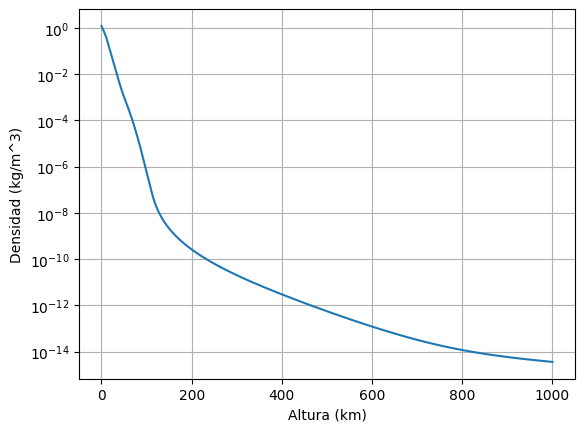

In [ ]:
pio.renderers.default = "png"
plt.plot(zs/1e3,data.rho)
plt.yscale('log')
plt.xlabel('Altitude (km)')
plt.ylabel('Density (kg/m^3)')
plt.grid()

### Methods:

The initial parameters of the problem are defined again so that they are not overwritten in the code:

In [ ]:
!pip install -Uq spiceypy
import spiceypy as spy

In [ ]:
CD = 2.2
D = 1 / UL # m
m = 100 / UM # kg
A = np.pi*D**2 / 4 # da en km^2
B = CD*A/m # Ballistic coefficient
D, A,B

(0.001, 7.853981633974482e-07, 1.727875959474386e-08)

In [ ]:
omegaE = 2*np.pi/((23+56/60)*3600)
omegaE

7.292462055686614e-05

In [ ]:
e0 = 0.052049
a0 = 6955 # km
I0 = 65.1*deg
Omega0 = 340*deg
omega0 = 58*deg
f0 = 332*deg

In [ ]:
q0 = a0*(1-e0) # Distance to periapsis
E0 = 2*np.arctan(np.sqrt((1-e0)/(1+e0))*np.tan(f0/2)) # Eccentric anomaly
M0 = E0 - e0*np.sin(E0) # Mean anomaly

In [ ]:
mu = G*ME
elts0 = [q0, e0, I0, Omega0, omega0, M0, 0, mu]
X0_ = spy.conics(elts0, 0)
r0_ = X0_[:3]
v0_ = X0_[3:]
r0_, v0_

(array([5874.08950934, -652.37085845, 3007.48671672]),
 array([-2.90069857,  4.09098138,  6.14446927]))

The total sampling time is defined; in this case, the time shown in Fig. 10.5 of the book is used, namely 120 days.

In [ ]:
t0 = 8 * 86400

Then, the distances to apogee (Q) and perigee (q) are defined; for ease of writing in the code, they are named $q_a$ and $q_p$, respectively:

In [ ]:
q_a0 = a0 * (1 + e0)
q_p0 = a0 * (1 - e0)

In [ ]:
q_a0, q_p0

(7317.000795, 6592.999205)

#### Euler method

Next, lists of the altitudes relative to Earth's surface are defined, so Earth's radius $(R_E)$ is subtracted from them:

In [ ]:
h_as = [q_a0 - RE]
h_ps = [q_p0 - RE]

A list for time, starting at zero, is defined:

In [ ]:
ts = [0]

The trick taught in class is used to see how the loop progresses:

In [ ]:
from tqdm import tqdm

A function for the Euler method is defined. It requires the parameter $\Delta t$, the vector containing the orbital parameters, $\mu$, and the total sampling time defined above:

Inside the function, a for loop runs over the sampling time using the relevant $\Delta t$. Then, the relative velocity, acceleration, new positions, and velocities are specified as before. From this, the new initial vector is found, and `spy.oscltx` is applied to obtain the new orbital parameters. The new altitudes and time, which depend on $\Delta t$, are then obtained. A condition is also included so that the process stops if the perigee altitude is below 100 km. Finally, the initial positions and velocities are redefined:

In [ ]:
def euler(delta_t, elts0, mu, t0):

  X0 = spy.conics(elts0, 0)
  r0 = X0[:3]
  v0 = X0[3:]
  ts = [0]

  for i in tqdm(range(int(t0 / delta_t))):

    # Calculate the relative velocity
    vrel_vec = v0 - np.cross(np.array([0,0,omegaE]),r0)
    vrel = np.linalg.norm(vrel_vec)

    # Calculate the acceleration
    ag = - mu*r0/np.linalg.norm(r0)**3
    rho = rho_fun(np.linalg.norm(r0)-RE) / URHO
    ad = - 1/2*rho*vrel*B*vrel_vec

    # Calculate the new position
    r = r0 + v0*delta_t

    # Calculate the new velocity
    v = v0 + (ag + ad)*delta_t

    # Orbital parameters
    X = np.hstack([r,v])
    q, e, I, Omega, omega, M, t, mu, f, a, P = spy.oscltx(X, 0, mu)

    q_a = a * (1 + e)
    q_p = a * (1 - e)

    # Altitudes
    h_as.append(q_a - RE)
    h_ps.append(q_p - RE)
    ts.append(ts[-1] + delta_t)

    if h_ps[-1] < 100:
        break

    r0 = r
    v0 = v

  return h_as, h_ps, ts

The function is called with $\Delta t = 30\,s$

In [ ]:
delta_t = 30
h_as, h_ps, ts = euler(delta_t, elts0, mu, t0)

100%|██████████| 23040/23040 [00:03<00:00, 5893.64it/s]


The results are converted to arrays:

In [ ]:
ts = np.array(ts)
h_as = np.array(h_as)
h_ps = np.array(h_ps)

The results are plotted:

In [ ]:
pio.renderers.default = "png"
fig1 = go.Figure()
fig1.add_trace(go.Scatter(x=ts/86400, y=h_as,
                          mode='lines', name='Apogee'))
fig1.add_trace(go.Scatter(x=ts/86400, y=h_ps,
                          mode='lines', name='Perigee'))
fig1.update_layout(
    title="Evolution of Apogee and Perigee with the Euler Method",
    xaxis_title="Time (Days)",
    yaxis_title="Altitude (km)"
)
fig1.show()

#### Leap-Frog method

For the Leap-Frog method, the previous procedure is repeated, changing the names of lists and variables and changing the order of the position and velocity calculations as defined by the method:

In [ ]:
t_prueba = 8 * 86400

In [ ]:
def leap_frog(delta_t1, elts0, mu, t):

  X0 = spy.conics(elts0, 0)
  r0 = X0[:3]
  v0 = X0[3:]

  ts1 = [0]
  h_as1 = [q_a0 - RE]
  h_ps1 = [q_p0 - RE]

  for i in tqdm(range(int(t / delta_t1))):

    # Calculate the relative velocity
    vrel_vec = v0 - np.cross(np.array([0,0,omegaE]),r0)
    vrel = np.linalg.norm(vrel_vec)

    # Calculate the acceleration
    ag = - mu*r0/np.linalg.norm(r0)**3
    rho = rho_fun(np.linalg.norm(r0)-RE) / URHO
    ad = - 1/2*rho*vrel*B*vrel_vec

    # Calculate the new velocity
    v = v0 + (ag + ad)*delta_t1

    # Calculate the new position
    r = r0 + v*delta_t1

    # Orbital parameters
    X = np.concatenate((r,v))
    q, e, I, Omega, omega, M, t, mu, f, a, P = spy.oscltx(X, 0, mu)

    q_p = q
    q_a = q * (1 + e) / (1 - e)


    # Altitudes
    h_as1.append(q_a - RE)
    h_ps1.append(q_p - RE)


    if (h_ps1[-1] <= 100 and h_as1[-1] <= 100):
      ts1.append(ts1[-1] + delta_t1)
      break
    r0 = r
    v0 = v

    ts1.append(ts1[-1] + delta_t1)

  return h_as1, h_ps1, ts1

The function is called with $\Delta t = 35\,s$

In [ ]:
delta_t1 = 35
h_as1, h_ps1, ts1 = leap_frog(delta_t1, elts0, mu, t_prueba)

 93%|█████████▎| 18441/19748 [00:02<00:00, 7284.31it/s]


In [ ]:
ts1 = np.array(ts1)
h_as1 = np.array(h_as1)
h_ps1 = np.array(h_ps1)

In [ ]:
print(len(ts1))
print(len(h_as1))
print(len(h_ps1))

18443
18443
18443


In [ ]:
pio.renderers.default = "png"
fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=ts1/86400, y=h_as1,
                          mode='lines', name='Apogee'))
fig2.add_trace(go.Scatter(x=ts1/86400, y=h_ps1,
                          mode='lines', name='Perigee'))
fig2.update_layout(
    title="Evolution of Apogee and Perigee with the Leap-Frog Method",
    xaxis_title="Time (Days)",
    yaxis_title="Altitude (km)"
)
fig2.show()

#### Numerical integration

The Cowell-method functions and the function representing reentry are defined:

In [ ]:
def ecuaciones_cowell(t, X, mu, B, omega):
  r = X[:3]
  v = X[3:]

  drdt = v

  vrel_vec = v - np.cross(np.array([0,0,omega]),r)
  vrel = np.linalg.norm(vrel_vec)
  rho = rho_fun(np.linalg.norm(r)-RE) / URHO

  dvdt = -mu*r/np.linalg.norm(r)**3 - 1/2*rho*vrel*B*vrel_vec


  return np.concatenate([drdt,dvdt])

In [ ]:
def reentrada(t, X, mu, B, omega):
  r = X[:3]
  v = X[3:]
  h = np.linalg.norm(r) - RE
  return h - 100

entrada_atmosfera.terminal = True
entrada_atmosfera.direction = -1

In [ ]:
from scipy.integrate import solve_ivp

In [ ]:
ts2 = np.linspace(0, 8*86400, 5000)

In [ ]:
def soluciones(funcion, evento, X, ts):
  solucion = solve_ivp(funcion, [ts[0], ts[-1]], X, t_eval=ts, args=(mu,B,omegaE), method='Radau', events=evento)
  return solucion

In [ ]:
solucion_cowell = soluciones(ecuaciones_cowell, entrada_atmosfera, X0, ts2)

In [ ]:
print(f"Reentry occurs at {solucion_cowell.t_events[0][0] / 86400:.2f} days")

La reentrada se da en 7.52 días


In [ ]:
print(type(solucion_cowell))

<class 'scipy.integrate._ivp.ivp.OdeResult'>


In [ ]:
rs_cowell = solucion_cowell.y[:3].T
vs_cowell = solucion_cowell.y[3:].T
ts_cowell = solucion_cowell.t
X_cowell = solucion_cowell.y.T

In [ ]:
h_as_cowell = []
h_ps_cowell = []

In [ ]:
for i, xs in enumerate(X_cowell):
    xs = xs.copy()
    q, e, I, Omega, omega, M, t, mu, f, a, P = spy.oscltx(xs, ts_cowell[i], mu)

    q_p = q
    q_a = q * (1 + e) / (1 - e)


    # Altitudes
    h_as_cowell.append(q_a - RE)
    h_ps_cowell.append(q_p - RE)


In [ ]:
h_as_cowell = np.array(h_as_cowell)
h_ps_cowell = np.array(h_ps_cowell)

In [ ]:
pio.renderers.default = "png"
fig3 = go.Figure()
fig3.add_trace(go.Scatter(x=ts_cowell/86400, y=h_as_cowell,
                          mode='lines', name='Apogee'))
fig3.add_trace(go.Scatter(x=ts_cowell/86400, y=h_ps_cowell,
                          mode='lines', name='Perigee'))
fig3.update_layout(
    title="Evolution of Apogee and Perigee with the Cowell Method",
    xaxis_title="Time (Days)",
    yaxis_title="Altitude (km)"
)
fig3.show()